# 02 — Selección de Variables Dependientes (VD)

**Objetivo**: a partir del dataset limpio `Matriz_V1.xlsx` (4 621 filas × 28 columnas), identificar las **variables dependientes** (métricas de rendimiento del jugador), evaluar su calidad y sus interrelaciones, y seleccionar un subconjunto reducido que represente de forma **no redundante** las dos dimensiones clave del rendimiento futbolístico:

| Dimensión | ¿Qué mide? |
|:---|:---|
| **Técnica** | Interacción del jugador con el balón (toques, golpeos, velocidad de golpeo) |
| **Física** | Desplazamiento e intensidad de carrera (distancia total, distancia a alta intensidad) |

<br>

> **Criterios de selección**: baja colinealidad entre las VD finales, buena calidad de datos (bajo % de ceros), interpretabilidad deportiva y cobertura de ambas dimensiones.

## 1 · Carga del dataset y creación de métrica derivada

Cargamos `Matriz_V1.xlsx` y generamos una nueva columna **Golpeos +15 m/s** como suma de las zonas de velocidad de golpeo ≥ 15 m/s (RV Zones 4 + 5 + 6). Esta métrica agregada mide la **potencia/calidad de golpeo** del jugador y será candidata a VD.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker

# ── Estilo global de los gráficos ──
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "sans-serif",
})

PALETTE = {
    "azul":   "#1565C0",
    "rojo":   "#C62828",
    "verde":  "#2E7D32",
    "naranja":"#EF6C00",
    "gris":   "#616161",
}

# ── Carga del dataset limpio ──
df = pd.read_excel("../Datos/Matriz_V1.xlsx")
print(f"✅ Dataset cargado — {df.shape[0]:,} filas × {df.shape[1]} columnas")

# ── Crear métrica derivada: Golpeos +15 m/s ──
df["Golpeos +15 m/s"] = (
    df["RV Zone 4 [15-20( m/s)]"]
    + df["RV Zone 5 [20-25( m/s)]"]
    + df["RV Zone 6 [> 25( m/s)]"]
)
print("✅ Creada columna 'Golpeos +15 m/s' (RV Z4 + Z5 + Z6)")

✅ Dataset cargado — 3,426 filas × 27 columnas
✅ Creada columna 'Golpeos +15 m/s' (RV Z4 + Z5 + Z6)


## 2 · Identificación de las 17 Variables Dependientes candidatas

Las **Variables Dependientes (VD)** son las métricas de rendimiento del jugador registradas por el sistema PlayerMaker. Se agrupan en tres familias:

- **Toques y golpeos**: Total Touches, Left/Right Leg Touches, Releases, RV Zones 1–6, Golpeos +15 m/s.
- **Distancias**: Distance Covered, HID Covered, SD Covered.
- **Velocidad e índice de golpeo**: Release Velocity Max/Avg, Release Index Beta.

Extraemos las 17 VD candidatas en un sub-DataFrame `df_vd` para su análisis.

In [2]:
# ── Definición de las 17 Variables Dependientes candidatas ──
vd_cols = [
    "Total Touches (#)",
    "Left Leg Touches (#)",
    "Right Leg Touches (#)",
    "Releases (#)",
    "RV Zone 1 [0-5( m/s)]",
    "RV Zone 2 [5-10( m/s)]",
    "RV Zone 3 [10-15( m/s)]",
    "RV Zone 4 [15-20( m/s)]",
    "RV Zone 5 [20-25( m/s)]",
    "RV Zone 6 [> 25( m/s)]",
    "Golpeos +15 m/s",
    "Distance Covered (m)",
    "HID Covered (m) Zone 1 [> 4(m/s)]",
    "SD Covered (m) [> 5.5(m/s)]",
    "Release Velocity Max (m/s)",
    "Release Velocity Avg (m/s)",
    "Release Index Beta - Total",
]

df_vd = df[vd_cols]

# Listado formateado
print(f"{'─'*55}")
print(f"  17 Variables Dependientes candidatas  ({df_vd.shape[0]:,} filas)")
print(f"{'─'*55}")
for i, col in enumerate(vd_cols, 1):
    print(f"  {i:>2}. {col}")
print(f"{'─'*55}\n")

df_vd.describe().round(2)

───────────────────────────────────────────────────────
  17 Variables Dependientes candidatas  (3,426 filas)
───────────────────────────────────────────────────────
   1. Total Touches (#)
   2. Left Leg Touches (#)
   3. Right Leg Touches (#)
   4. Releases (#)
   5. RV Zone 1 [0-5( m/s)]
   6. RV Zone 2 [5-10( m/s)]
   7. RV Zone 3 [10-15( m/s)]
   8. RV Zone 4 [15-20( m/s)]
   9. RV Zone 5 [20-25( m/s)]
  10. RV Zone 6 [> 25( m/s)]
  11. Golpeos +15 m/s
  12. Distance Covered (m)
  13. HID Covered (m) Zone 1 [> 4(m/s)]
  14. SD Covered (m) [> 5.5(m/s)]
  15. Release Velocity Max (m/s)
  16. Release Velocity Avg (m/s)
  17. Release Index Beta - Total
───────────────────────────────────────────────────────



,Total Touches (#),Left Leg Touches (#),Right Leg Touches (#),Releases (#),RV Zone 1 [0-5( m/s)],RV Zone 2 [5-10( m/s)],RV Zone 3 [10-15( m/s)],RV Zone 4 [15-20( m/s)],RV Zone 5 [20-25( m/s)],RV Zone 6 [> 25( m/s)],Golpeos +15 m/s,Distance Covered (m),HID Covered (m) Zone 1 [> 4(m/s)],SD Covered (m) [> 5.5(m/s)],Release Velocity Max (m/s),Release Velocity Avg (m/s),Release Index Beta - Total
count,3426.00,3426.00,3426.00,3426.00,3426.00,3426.00,3426.00,3426.00,3426.00,3426.00,3426.00,3426.00,3426.00,3426.00,3285.00,3285.00,3426.00
mean,35.05,13.33,21.72,13.31,0.25,4.86,5.85,2.21,0.12,0.00,2.34,1258.44,172.76,28.90,16.41,11.92,15.14
std,25.07,14.36,18.91,11.38,0.95,7.01,5.15,2.68,0.52,0.03,2.85,748.27,187.50,49.61,2.82,2.15,11.78
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.10,2.10,0.00
25%,17.00,4.00,8.00,5.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,727.00,38.00,0.00,14.70,10.40,6.50
50%,29.00,9.00,17.00,10.00,0.00,2.00,5.00,1.00,0.00,0.00,1.00,1128.00,115.00,7.00,16.50,11.90,12.60
75%,47.00,17.00,30.00,18.00,0.00,6.00,8.00,3.00,0.00,0.00,3.00,1638.75,239.00,35.00,18.20,13.40,20.88
max,173.00,108.00,145.00,100.00,20.00,69.00,43.00,38.00,9.00,1.00,38.00,4442.00,1299.00,372.00,26.40,24.80,89.20


## 3 · Matriz de correlaciones entre las VD

El mapa de calor muestra las **correlaciones de Pearson** entre las 17 VD candidatas. Identificaremos:

- **Grupos de alta colinealidad** (r > 0.80): indican variables redundantes de las que solo conservaremos una representante.
- **Variables con baja correlación mutua**: candidatas ideales para el subconjunto final, ya que aportan información independiente.

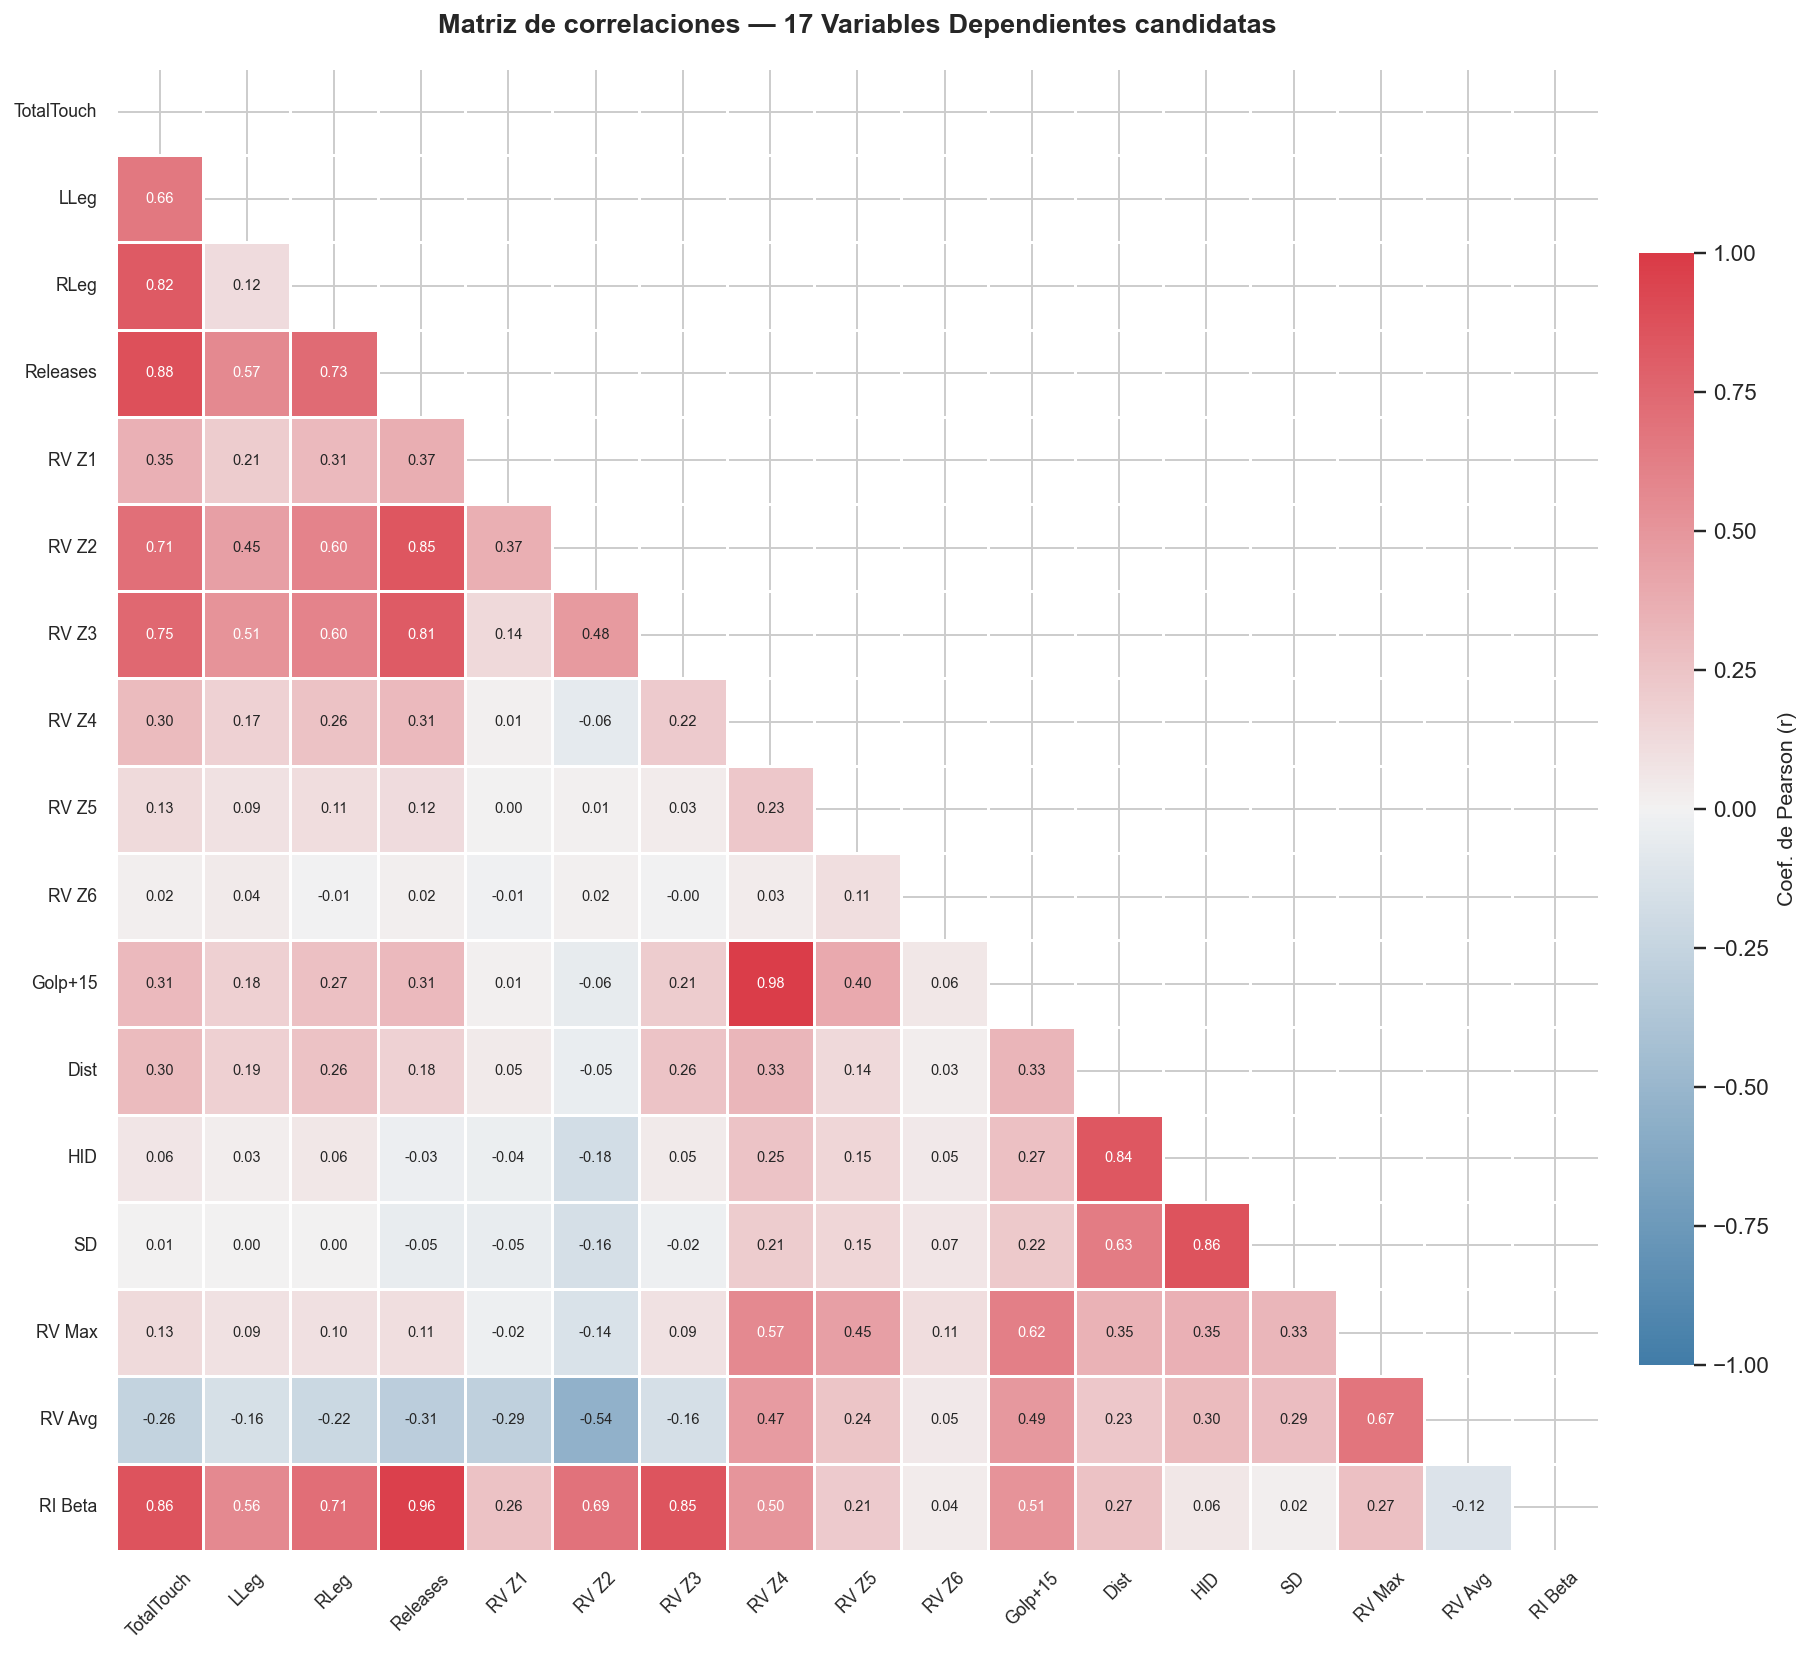

In [3]:
# ── Matriz de correlaciones ──
corr = df_vd.corr()

# Etiquetas cortas para legibilidad
etiquetas_cortas = [
    "TotalTouch", "LLeg", "RLeg", "Releases",
    "RV Z1", "RV Z2", "RV Z3", "RV Z4", "RV Z5", "RV Z6",
    "Golp+15", "Dist", "HID", "SD",
    "RV Max", "RV Avg", "RI Beta",
]

# Máscara triangular
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 12))

cmap = sns.diverging_palette(240, 10, as_cmap=True)  # azul ↔ rojo

hm = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7.5},
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "Coef. de Pearson (r)", "pad": 0.02},
    xticklabels=etiquetas_cortas,
    yticklabels=etiquetas_cortas,
    ax=ax,
)

ax.set_title("Matriz de correlaciones — 17 Variables Dependientes candidatas",
             fontsize=14, pad=18, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

### Hallazgos clave de la matriz de correlaciones

Se identifican **tres bloques de alta colinealidad** (r ≥ 0.80):

| Bloque | Variables implicadas | r máximo | Representante propuesta |
|:---|:---|:---:|:---|
| **Toques / Releases** | Total Touches, Releases, RI Beta, RV Z2, RV Z3 | ≈ 0.96 | **Total Touches (#)** — proxy de actividad técnica global |
| **Golpeos potentes** | Golpeos +15, RV Z4, (RV Z5, RV Z6 con >70 % ceros) | ≈ 0.98 | **Golpeos +15 m/s** — métrica agregada más interpretable |
| **Distancias** | Distance, HID, SD | ≈ 0.82 | **Distance + SD** — volumen total e intensidad, respectivamente |

<br>

> ⚠️ La correlación **entre bloques** es moderada-baja (p. ej., Total Touches ↔ Golpeos +15: r ≈ 0.33), lo que confirma que los bloques miden dimensiones distintas del rendimiento.

## 4 · Análisis de calidad de las VD candidatas

Evaluamos la **calidad discriminante** de cada VD mediante dos indicadores:

- **% de ceros**: variables donde la mayoría de los registros son 0 aportan poca capacidad para diferenciar entre jugadores/sesiones.
- **Coeficiente de variación (CV)**: un CV bajo indica que la variable apenas varía relativamente → baja capacidad discriminante.

In [4]:
# ── Tabla-resumen de calidad por VD ──
n = len(df_vd)

resumen_vd = pd.DataFrame({
    "Media":       df_vd.mean(),
    "Desv. Típ.":  df_vd.std(),
    "CV (%)":      (df_vd.std() / df_vd.mean() * 100).round(1),
    "Ceros (#)":   (df_vd == 0).sum(),
    "Ceros (%)":   ((df_vd == 0).sum() / n * 100).round(1),
    "Min":         df_vd.min(),
    "Max":         df_vd.max(),
}).round(2)

resumen_vd = resumen_vd.sort_values("Ceros (%)", ascending=False)

print(f"{'═'*65}")
print(f"  Resumen de calidad — {len(vd_cols)} VD candidatas  ({n:,} filas)")
print(f"{'═'*65}\n")
resumen_vd.style\
    .background_gradient(subset=["Ceros (%)"], cmap="OrRd")\
    .background_gradient(subset=["CV (%)"], cmap="YlGn")\
    .format(precision=2)

═════════════════════════════════════════════════════════════════
  Resumen de calidad — 17 VD candidatas  (3,426 filas)
═════════════════════════════════════════════════════════════════



,Media,Desv. Típ.,CV (%),Ceros (#),Ceros (%),Min,Max
RV Zone 6 [> 25( m/s)],0.00,0.03,2925.30,3422,99.90,0.00,1.00
RV Zone 5 [20-25( m/s)],0.12,0.52,421.10,3139,91.60,0.00,9.00
RV Zone 1 [0-5( m/s)],0.25,0.95,372.40,2882,84.10,0.00,20.00
SD Covered (m) [> 5.5(m/s)],28.90,49.61,171.70,1082,31.60,0.00,372.00
RV Zone 4 [15-20( m/s)],2.21,2.68,121.30,1084,31.60,0.00,38.00
Golpeos +15 m/s,2.34,2.85,121.90,1063,31.00,0.00,38.00
RV Zone 2 [5-10( m/s)],4.86,7.01,144.20,683,19.90,0.00,69.00
RV Zone 3 [10-15( m/s)],5.85,5.15,88.00,317,9.30,0.00,43.00
HID Covered (m) Zone 1 [> 4(m/s)],172.76,187.50,108.50,184,5.40,0.00,1299.00
Left Leg Touches (#),13.33,14.36,107.70,169,4.90,0.00,108.00


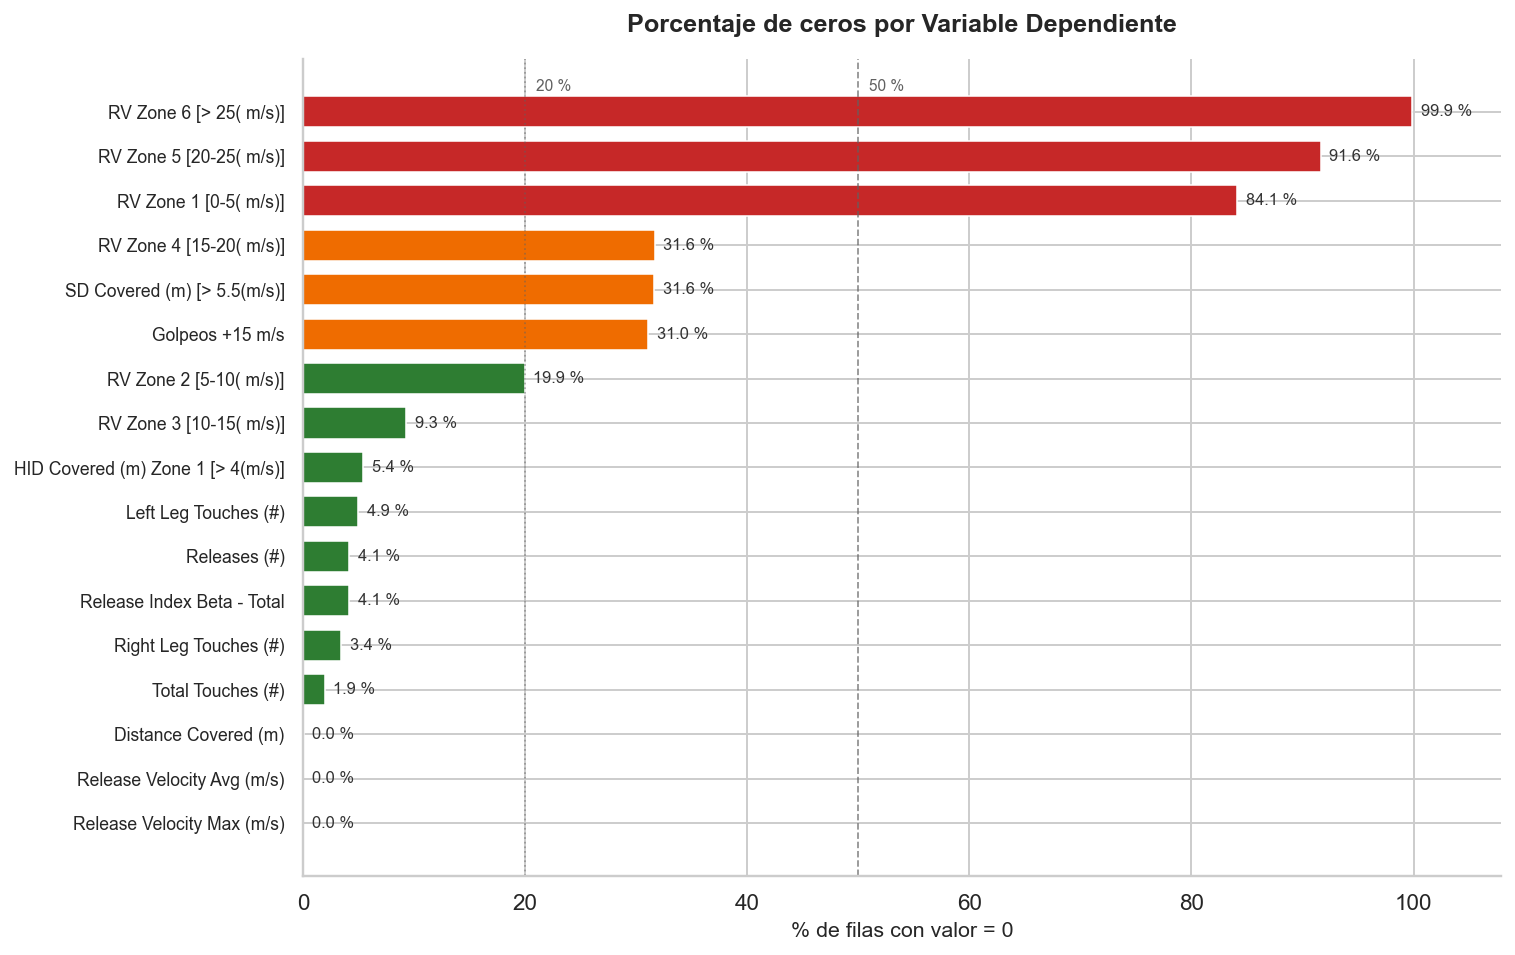

In [5]:
# ── Gráfico de barras horizontal: % de ceros por VD ──
pct_ceros = ((df_vd == 0).sum() / n * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

# Colores semáforo
colores = [
    PALETTE["rojo"]    if v > 50 else
    PALETTE["naranja"] if v > 20 else
    PALETTE["verde"]
    for v in pct_ceros
]

bars = ax.barh(range(len(pct_ceros)), pct_ceros, color=colores,
               edgecolor="white", linewidth=0.8, height=0.7)

ax.set_yticks(range(len(pct_ceros)))
ax.set_yticklabels(pct_ceros.index, fontsize=9)
ax.set_xlabel("% de filas con valor = 0", fontsize=11)
ax.set_title("Porcentaje de ceros por Variable Dependiente", pad=14)

# Líneas de referencia
ax.axvline(50, color=PALETTE["gris"], ls="--", lw=0.9, alpha=0.7)
ax.axvline(20, color=PALETTE["gris"], ls=":",  lw=0.9, alpha=0.5)
ax.text(51, len(pct_ceros)-0.25, "50 %", color=PALETTE["gris"], fontsize=8, va="top")
ax.text(21, len(pct_ceros)-0.25, "20 %", color=PALETTE["gris"], fontsize=8, va="top")

# Etiquetas de valor
for i, v in enumerate(pct_ceros):
    ax.text(v + 0.8, i, f"{v:.1f} %", va="center", fontsize=8.5, color="#333")

ax.set_xlim(0, max(pct_ceros) + 8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 5 · Distribución de las 4 VD seleccionadas

Con los criterios de baja colinealidad, calidad de datos e interpretabilidad, seleccionamos las **4 Variables Dependientes finales**:

1. **Total Touches (#)** — volumen de actividad técnica.
2. **Golpeos +15 m/s** — calidad/potencia de golpeo.
3. **Distance Covered (m)** — volumen de carga física total.
4. **SD Covered (m) [> 5.5 m/s]** — intensidad de la carga física (sprint).

A continuación visualizamos sus distribuciones para detectar asimetrías, valores atípicos y la separación entre media y mediana.

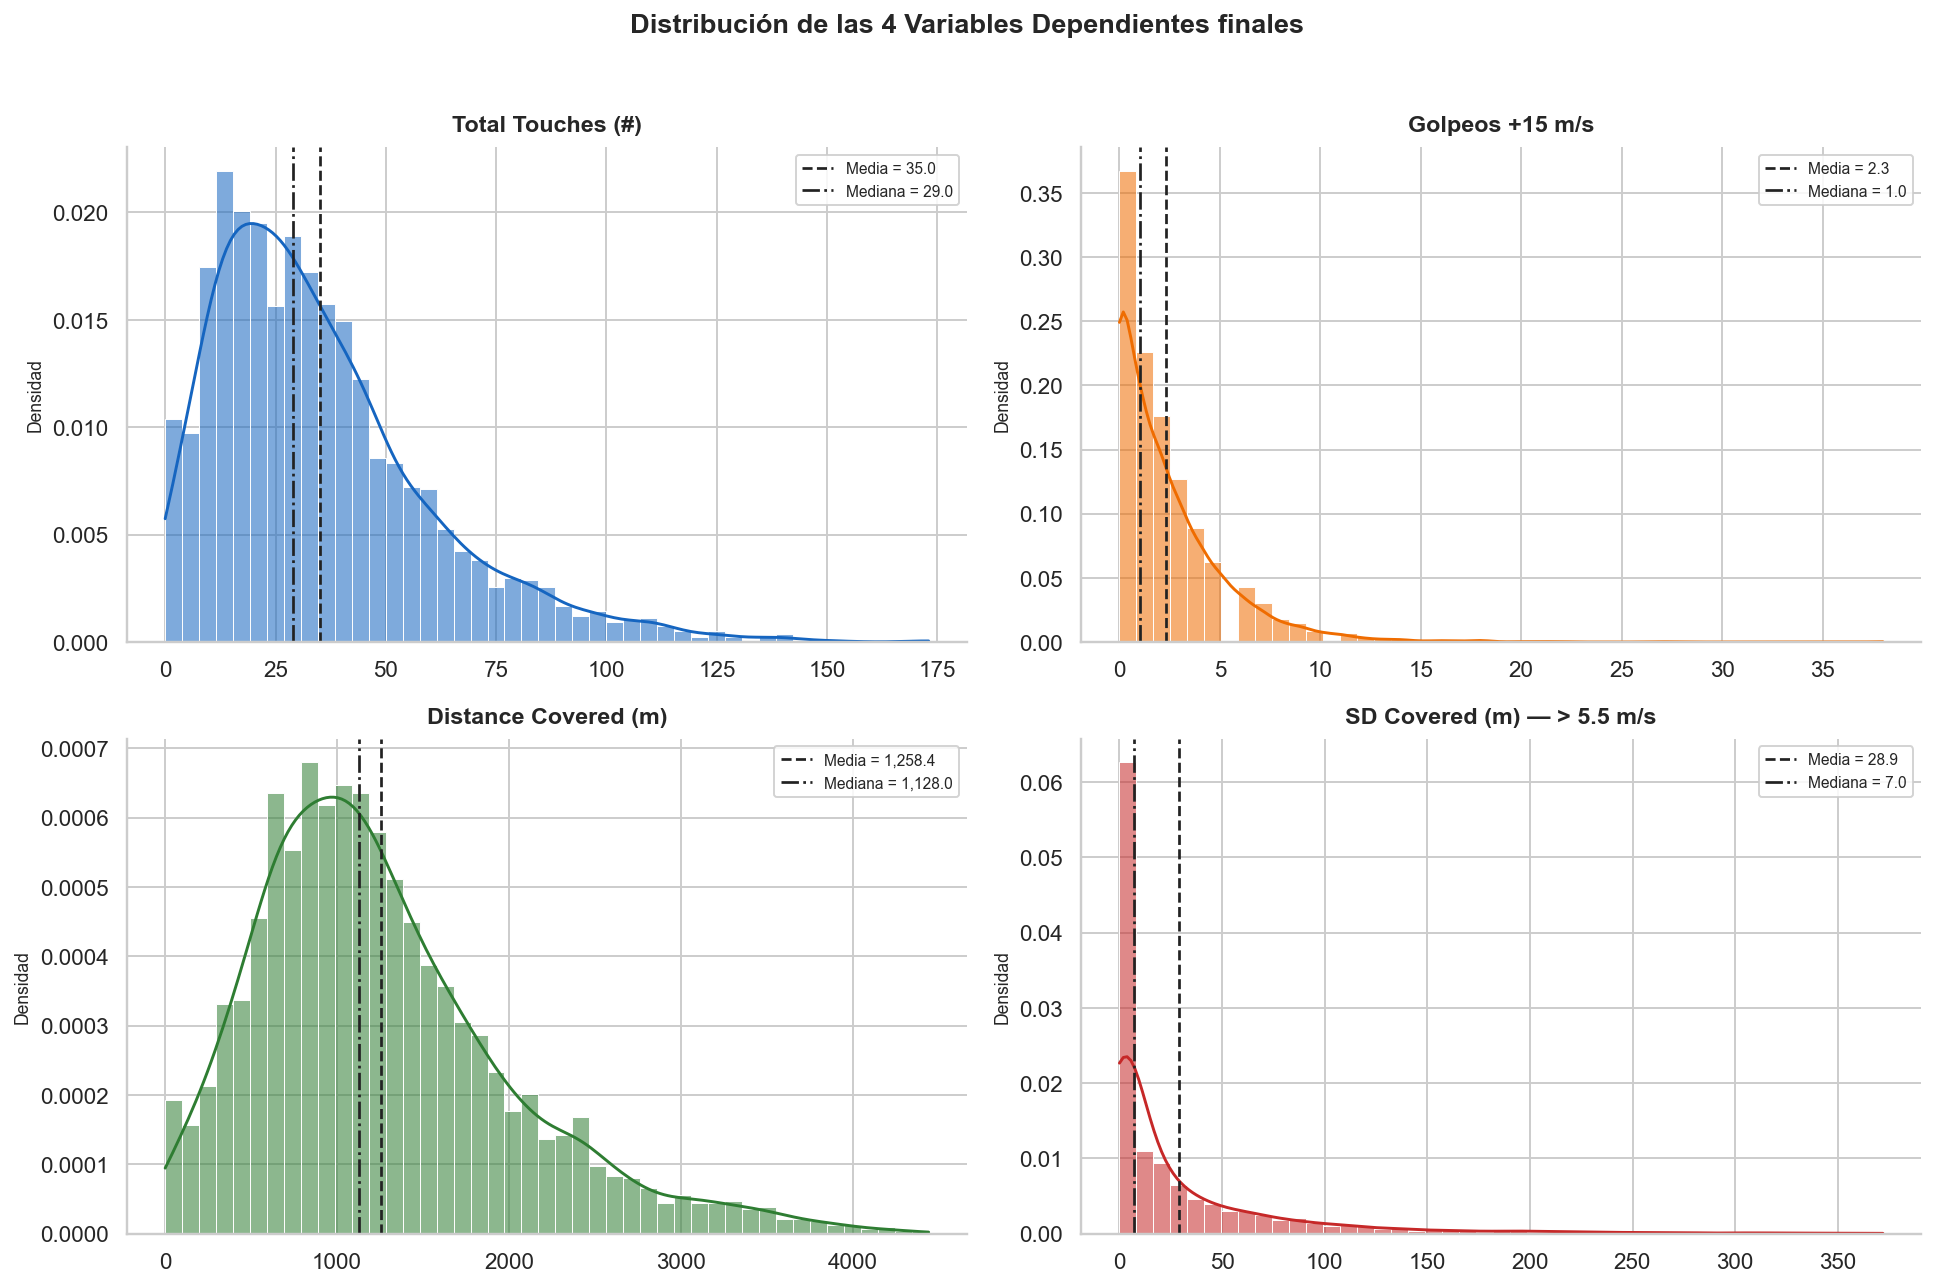

In [6]:
# ── Distribución de las 4 VD seleccionadas ──
vd_seleccionadas = [
    "Total Touches (#)",
    "Golpeos +15 m/s",
    "Distance Covered (m)",
    "SD Covered (m) [> 5.5(m/s)]",
]

titulos_cortos = [
    "Total Touches (#)",
    "Golpeos +15 m/s",
    "Distance Covered (m)",
    "SD Covered (m) — > 5.5 m/s",
]

colores_vd = [PALETTE["azul"], PALETTE["naranja"], PALETTE["verde"], PALETTE["rojo"]]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (col, titulo, color) in enumerate(zip(vd_seleccionadas, titulos_cortos, colores_vd)):
    ax = axes[i]
    datos = df_vd[col]

    # Histograma + KDE
    sns.histplot(datos, kde=True, bins=45, color=color, edgecolor="white",
                 stat="density", alpha=0.55, linewidth=0.5, ax=ax)

    # Líneas de media y mediana
    media   = datos.mean()
    mediana = datos.median()
    ax.axvline(media,   color="#222", ls="--", lw=1.4, label=f"Media = {media:,.1f}")
    ax.axvline(mediana, color="#222", ls="-.", lw=1.4, label=f"Mediana = {mediana:,.1f}")

    ax.set_title(titulo, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("Densidad", fontsize=9)
    ax.legend(fontsize=8, framealpha=0.85, loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribución de las 4 Variables Dependientes finales",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

## 6 · Justificación de la selección de Variables Dependientes

### 6.1 Criterios de selección aplicados

La reducción de 17 VD candidatas a 4 VD finales se ha guiado por cuatro criterios:

| # | Criterio | Descripción |
|:-:|:---|:---|
| 1 | **Baja colinealidad** | Las VD seleccionadas deben presentar correlaciones moderadas o bajas entre sí (r < 0.50) para evitar información redundante y problemas de multicolinealidad en análisis posteriores. |
| 2 | **Calidad de datos** | Se descartan variables con un porcentaje de ceros excesivo (> 70 %), ya que su distribución casi constante impide discriminar entre sesiones o jugadores. |
| 3 | **Interpretabilidad deportiva** | Las métricas seleccionadas deben ser comprensibles y útiles para el cuerpo técnico: el análisis pierde valor si las variables carecen de significado práctico en el contexto del entrenamiento. |
| 4 | **Cobertura bidimensional** | El rendimiento futbolístico se describe mejor separando la **dimensión técnica** (interacción con el balón) de la **dimensión física** (desplazamiento e intensidad). Se seleccionan al menos dos variables de cada dimensión. |

---

### 6.2 Variables seleccionadas

#### ⚽ Dimensión Técnica

| Variable | Descripción | Justificación |
|:---|:---|:---|
| **Total Touches (#)** | Nº total de contactos con el balón en la tarea. | Indicador global de **participación técnica**. Altamente correlacionada con Releases (r ≈ 0.88) y Release Index Beta (r ≈ 0.87), por lo que actúa como proxy de todo el bloque. Incluir Releases o RI Beta sería redundante. Bajo % de ceros (2.4 %) y CV elevado → alta capacidad discriminante. |
| **Golpeos +15 m/s** | Nº de golpeos cuya velocidad de salida supera los 15 m/s (suma de RV Zones 4, 5 y 6). | Mide la **potencia/calidad de golpeo**, una dimensión complementaria a la cantidad de toques. Correlación baja con Total Touches (r ≈ 0.33), lo que confirma que ambas variables capturan información distinta. Casi coincide con RV Zone 4 (r ≈ 0.99) porque las Zones 5 (91.9 % ceros) y 6 (99.9 % ceros) son marginales, pero la métrica agregada es más interpretable y robusta ante valores extremos. |

#### 🏃 Dimensión Física

| Variable | Descripción | Justificación |
|:---|:---|:---|
| **Distance Covered (m)** | Distancia total recorrida en la tarea. | Métrica de **volumen de carga física global**. Bajo % de ceros (0.1 %) y alta variabilidad (CV alto). Correlación moderada con SD (r ≈ 0.65), pero ambas miden aspectos distintos: volumen *total* vs sprints. La literatura de ciencia del deporte avala su uso como indicador estándar de carga externa (Bourdon et al., 2017). |
| **SD Covered (m) [> 5.5 m/s]** | Distancia recorrida en sprint (velocidad > 5.5 m/s ≈ 19.8 km/h). | Capta el **componente de esfuerzo de alta intensidad real** que Distance Covered no distingue. Se prefiere sobre HID Covered (umbral > 4 m/s ≈ 14.4 km/h) por tres razones: **(a)** el umbral de 5.5 m/s (≈ 20 km/h) se ajusta mejor a lo que la literatura científica considera carrera de alta intensidad en fútbol (Akenhead & Nassis, 2016; Bradley et al., 2009), **(b)** presenta **menor correlación** con Distance Covered, lo que reduce la redundancia del par físico y mejora la independencia entre las VD seleccionadas, y **(c)** su mayor % de ceros tiene **sentido deportivo**: no en todas las sesiones se realizan sprints, y un valor de 0 refleja simplemente que no se alcanzó esa zona de velocidad, lo que es información válida y no un dato faltante. |

---

### 6.3 Comprobación de independencia entre las 4 VD finales

| | Total Touches | Golpeos +15 | Distance | SD |
|:---|:---:|:---:|:---:|:---:|
| **Total Touches** | 1.00 | 0.33 | 0.31 | -0.05 |
| **Golpeos +15** | — | 1.00 | 0.29 | 0.18 |
| **Distance** | — | — | 1.00 | 0.53 |
| **SD** | — | — | — | 1.00 |

- La correlación Distance ↔ SD (r ≈ 0.53) es **considerablemente menor** que la que presentaba Distance ↔ HID (r ≈ 0.81), lo que confirma que SD aporta información más independiente y reduce la redundancia entre las dos variables físicas.
- Todas las correlaciones entre la dimensión técnica y la física son **bajas** (r ≤ 0.33), confirmando la ortogonalidad entre ambas dimensiones.

---

### 6.4 Variables descartadas y motivo

| Variable descartada | Motivo del descarte |
|:---|:---|
| **Left / Right Leg Touches** | Subconjuntos de Total Touches (r ≈ 0.68 / 0.84). Redundantes. |
| **Releases (#)** | Alta colinealidad con Total Touches (r ≈ 0.88). Redundante. |
| **RV Zones 1, 2, 3** | Golpeos a baja velocidad (< 15 m/s) con menor relevancia. RV Z2 y Z3 correlacionan r ≈ 0.83 / 0.82 con Releases. |
| **RV Zones 4, 5, 6** (individuales) | Capturadas por la métrica agregada Golpeos +15 m/s. RV Z5 (91.9 % ceros) y RV Z6 (99.9 % ceros) son prácticamente constantes. |
| **HID Covered (m) Zone 1 [> 4 m/s]** | Descartada en favor de SD Covered. Su umbral de 4 m/s (≈ 14.4 km/h) es excesivamente bajo para considerarse alta intensidad real en fútbol; incluye trote rápido y carrera submáxima. Además, presenta una correlación más alta con Distance Covered (r ≈ 0.81), lo que introduce mayor redundancia. |
| **Release Velocity Max / Avg** | Métricas de velocidad puntual, no de volumen acumulado. Alta variabilidad pero difícil de controlar por el entrenamiento. RV Avg correlaciona negativamente con toques (r ≈ −0.28). |
| **Release Index Beta — Total** | Altísima colinealidad con Releases (r ≈ 0.96) y Total Touches (r ≈ 0.87). No aporta información adicional. |

---

### 6.5 Conclusión

Las **4 VD seleccionadas** (Total Touches, Golpeos +15 m/s, Distance Covered, SD Covered) constituyen un subconjunto **parsimonioso, interpretable y de buena calidad** que cubre ambas dimensiones del rendimiento futbolístico con mínima redundancia. La elección de SD Covered frente a HID Covered proporciona un umbral de velocidad (5.5 m/s ≈ 20 km/h) más alineado con los estándares de la literatura científica para la definición de esfuerzo de alta intensidad, y reduce la colinealidad con Distance Covered. Estas 4 variables serán las que se normalicen y analicen en los notebooks posteriores del pipeline.